In [1153]:
import pandas as pd 
import numpy as np
from IPython.display import display
import sys, os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
import missingno as msno
%matplotlib inline
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
#from functions.transformers import *
from functions.eda_functions import test_mcar, list_missing_values

In [1154]:
useTrain = pd.read_csv("../data/processed/train_missing_values.csv", keep_default_na=False)

In [1155]:
#PoolQC: Calidad de la piscina.
dsPoolQCLabels = useTrain['PoolQC'].unique().tolist()
#Reportados en el documento
docsPoolQCLabels = ['Ex', 'Gd', 'TA', 'Fa', 'NA']
misssingPoolQCLabels = list(set(dsPoolQCLabels) - set(docsPoolQCLabels))
display(misssingPoolQCLabels)
#Ordinal encoding/Label encoding
#{ Ex: 4, Gd: 3, TA: 2, Fa: 1, NA: 0}
poolqc_mapping = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'NA': 0}
useTrain['PoolQC'] = useTrain['PoolQC'].map(poolqc_mapping)

[]

In [1156]:
#MiscFeature: Característica miscelánea no cubierta en otras categorías.
dsMiscFeatureLabels = useTrain['MiscFeature'].unique().tolist()
#Reportados en el documento
docsMiscFeatureLabels = ['Elev', 'Gar2', 'Othr', 'Shed', 'TenC', 'NA']
misssingMiscFeatureLabels = list(set(dsMiscFeatureLabels) - set(docsMiscFeatureLabels))
display(misssingMiscFeatureLabels)
#Apliquemos Dummy encoding para MiscFeature.
useTrain = pd.get_dummies(useTrain, columns=['MiscFeature'], prefix='MiscFeature', dtype=int)
useTrain = useTrain.drop(columns=['MiscFeature_NA'])

[]

In [1157]:
#Alley: Tipo de acceso por callejón a la propiedad.
dsAlleyLabels = useTrain['Alley'].unique().tolist()
#Reportados en el documento
docsAlleyLabels = ['Grvl', 'Pave', 'NA']
misssingAlleyLabels = list(set(dsAlleyLabels) - set(docsAlleyLabels))
display(misssingAlleyLabels)
#Apliquemos Dummy encoding para Alley.
useTrain = pd.get_dummies(useTrain, columns=['Alley'], prefix='Alley', dtype=int)
useTrain = useTrain.drop(columns=['Alley_NA'])

[]

In [1158]:
#Fence: Calidad de la cerca.
dsFenceLabels = useTrain['Fence'].unique().tolist()
#Reportados en el documento
docsFenceLabels = ['GdPrv', 'MnPrv', 'GdWo', 'MnWw', 'NA']
misssingFenceLabels = list(set(dsFenceLabels) - set(docsFenceLabels))
display(misssingFenceLabels)
#Apliquemos ordinal encoding/Label encoding para Fence.
fence_mapping = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0}
useTrain['Fence'] = useTrain['Fence'].map(fence_mapping)
#🎈Quiza se pueda cambiar a dummy encoding

[]

In [1159]:
#MasVnrType: Tipo de revestimiento de mampostería.
dsMasVnrTypeLabels = useTrain['MasVnrType'].unique().tolist()
#Reportados en el documento
docsMasVnrTypeLabels = ['BrkCmn', 'BrkFace', 'CBlock', 'None', 'Stone']
misssingMasVnrTypeLabels = list(set(dsMasVnrTypeLabels) - set(docsMasVnrTypeLabels))
display(misssingMasVnrTypeLabels)
#Apliquemos ordinal encoding/Label encoding para MasVnrType.
masvnrtype_mapping = {'BrkCmn': 1, 'BrkFace': 2, 'CBlock': 3, 'None': 0, 'Stone': 4}
useTrain['MasVnrType'] = useTrain['MasVnrType'].map(masvnrtype_mapping)

[]

In [1160]:
#FireplaceQu: Calidad de la chimenea.
dsFireplaceQuLabels = useTrain['FireplaceQu'].unique().tolist()
#Reportados en el documento
docsFireplaceQuLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
misssingFireplaceQuLabels = list(set(dsFireplaceQuLabels) - set(docsFireplaceQuLabels))
display(misssingFireplaceQuLabels)
#Apliquemos ordinal encoding/Label encoding para FireplaceQu.
fireplacequ_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
useTrain['FireplaceQu'] = useTrain['FireplaceQu'].map(fireplacequ_mapping)

[]

In [1161]:
#GarageQual: Calidad del garaje.
dsGarageQualLabels = useTrain['GarageQual'].unique().tolist()
#Reportados en el documento
docsGarageQualLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
misssingGarageQualLabels = list(set(dsGarageQualLabels) - set(docsGarageQualLabels))
display(misssingGarageQualLabels)
#Apliquemos ordinal encoding/Label encoding para GarageQual.
garagequal_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
useTrain['GarageQual'] = useTrain['GarageQual'].map(garagequal_mapping)

[]

In [1162]:
#GarageType: Ubicación del garaje.
dsGarageTypeLabels = useTrain['GarageType'].unique().tolist()
#Reportados en el documento
docsGarageTypeLabels = ['2Types', 'Attchd', 'Basment', 'BuiltIn', 'CarPort', 'Detchd', 'NA']
misssingGarageTypeLabels = list(set(dsGarageTypeLabels) - set(docsGarageTypeLabels))
display(misssingGarageTypeLabels)
#Apliquemos Dummy encoding para GarageType.
useTrain = pd.get_dummies(useTrain, columns=['GarageType'], prefix='GarageType', dtype=int)
useTrain = useTrain.drop(columns=['GarageType_NA'])
#🎈Se puece analizar por ordinal encoding

[]

In [1163]:
#GarageFinish: Finalización del garaje.
dsGarageFinishLabels = useTrain['GarageFinish'].unique().tolist()
#reportados en el documento
docsGarageFinishLabels = ['Fin', 'RFn', 'Unf', 'NA']
misssingGarageFinishLabels = list(set(dsGarageFinishLabels) - set(docsGarageFinishLabels))
display(misssingGarageFinishLabels)
#ordinal encoding/Label encoding para GarageFinish.
garagefinish_mapping = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NA': 0}
useTrain['GarageFinish'] = useTrain['GarageFinish'].map(garagefinish_mapping)

[]

In [1164]:
#GarageCond: Condición del garaje.
dsGarageCondLabels = useTrain['GarageCond'].unique().tolist()
#reportados en el documento
docsGarageCondLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
misssingGarageCondLabels = list(set(dsGarageCondLabels) - set(docsGarageCondLabels))
display(misssingGarageCondLabels)
#ordinal encoding/Label encoding para GarageCond.
garagecond_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
useTrain['GarageCond'] = useTrain['GarageCond'].map(garagecond_mapping)

[]

In [1165]:
#BsmtExposure: Se refiere a las paredes del sótano a nivel de jardín o con salida.
dsBsmtExposureLabels = useTrain['BsmtExposure'].unique().tolist()
docsBsmtExposureLabels = ['Gd', 'Av', 'Mn', 'No', 'NA']
misssingBsmtExposureLabels = list(set(dsBsmtExposureLabels) - set(docsBsmtExposureLabels))
display(misssingBsmtExposureLabels)
#ordinal encoding/Label encoding para BsmtExposure.
bsmtexposure_mapping = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0}
useTrain['BsmtExposure'] = useTrain['BsmtExposure'].map(bsmtexposure_mapping)

[]

In [1166]:
#BsmtFinType2: Calificación del área terminada del sótano (si hay varios tipos).
dsBsmtFinType2Labels = useTrain['BsmtFinType2'].unique().tolist()
docsBsmtFinType2Labels = ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA']
misssingBsmtFinType2Labels = list(set(dsBsmtFinType2Labels) - set(docsBsmtFinType2Labels))
display(misssingBsmtFinType2Labels)
#ordinal encoding/Label encoding para BsmtFinType2.
bsmtfintype2_mapping = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0}
useTrain['BsmtFinType2'] = useTrain['BsmtFinType2'].map(bsmtfintype2_mapping)

[]

In [1167]:
#BsmtQual: Evalúa la altura del sótano.
dsBsmtQualLabels = useTrain['BsmtQual'].unique().tolist()
docsBsmtQualLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
misssingBsmtQualLabels = list(set(dsBsmtQualLabels) - set(docsBsmtQualLabels))
display(misssingBsmtQualLabels)
#ordinal encoding/Label encoding para BsmtQual.
bsmqual_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
useTrain['BsmtQual'] = useTrain['BsmtQual'].map(bsmqual_mapping)

[]

In [1168]:
#BsmtFinType1: Calificación del área terminada del sótano.
dsBsmtFinType1Labels = useTrain['BsmtFinType1'].unique().tolist()
docsBsmtFinType1Labels = ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA']
misssingBsmtFinType1Labels = list(set(dsBsmtFinType1Labels) - set(docsBsmtFinType1Labels))
display(misssingBsmtFinType1Labels)
#ordinal encoding/Label encoding para BsmtFinType1.
bsmtfintype1_mapping = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0}
useTrain['BsmtFinType1'] = useTrain['BsmtFinType1'].map(bsmtfintype1_mapping)

[]

In [1169]:
#BsmtCond: Evalúa la condición general del sótano.
dsBsmtCondLabels = useTrain['BsmtCond'].unique().tolist()
docsBsmtCondLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
misssingBsmtCondLabels = list(set(dsBsmtCondLabels) - set(docsBsmtCondLabels))
display(misssingBsmtCondLabels)
#ordinal encoding/Label encoding para BsmtCond.
bsmtcond_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
useTrain['BsmtCond'] = useTrain['BsmtCond'].map(bsmtcond_mapping)

[]

In [1170]:
#Electrical: Sistema eléctrico.
dsElectricalLabels = useTrain['Electrical'].unique().tolist()
docsElectricalLabels = ['SBrkr', 'FuseA', 'FuseF', 'FuseP', 'Mix']
misssingElectricalLabels = list(set(dsElectricalLabels) - set(docsElectricalLabels))
display(misssingElectricalLabels)
#one hot encoding para Electrical.
useTrain = pd.get_dummies(useTrain, columns=['Electrical'], prefix='Electrical', dtype=int, drop_first=True)

[]

In [1171]:
cols_estandarization = ["BldgType"]
for col in cols_estandarization:
    if col in useTrain.columns:
        useTrain[col] = useTrain[col].str.lower()

In [1172]:
#BldgType: Tipo de vivienda.
dsBldgTypeLabels = useTrain['BldgType'].unique().tolist()
docsBldgTypeLabels = ['1fam', '2fmcon', 'duplex', 'twnhs', 'twnhse']
misssingBldgTypeLabels = list(set(dsBldgTypeLabels) - set(docsBldgTypeLabels))
display(misssingBldgTypeLabels)
useTrain['BldgType'] = useTrain['BldgType'].replace('2fmcon', '2fmcon')  # Corregir la etiqueta si es necesario
#ordinal encoding/Label encoding para BldgType.
bldgtype_mapping = {'1fam': 5, '2fmcon': 4, 'duplex': 3, 'twnhs': 2, 'twnhse': 1}
useTrain['BldgType'] = useTrain['BldgType'].map(bldgtype_mapping)
#🎈 puede aplicarle dummy encoding

[]

In [1173]:
#Neighborhood: Ubicaciones físicas dentro de los límites de la ciudad de Ames.
dsNeighborhoodLabels = useTrain['Neighborhood'].unique().tolist()
docsNeighborhoodLabels = ['Blmngtn','Blueste','BrDale','BrkSide','ClearCr',
                          'CollgCr','Crawfor','Edwards','Gilbert','IDOTRR',
                          'MeadowV','Mitchel','Names','NoRidge','NPkVill',
                          'NridgHt','NWAmes','OldTown','SWISU','Sawyer','SawyerW',
                          'Somerst','StoneBr','Timber','Veenker']
misssingNeighborhoodLabels = list(set(dsNeighborhoodLabels) - set(docsNeighborhoodLabels))
display(misssingNeighborhoodLabels)
useTrain['Neighborhood'] = useTrain['Neighborhood'].replace('NAmes', 'Names')
#🎈 puede aplicarle dummy encoding
useTrain = pd.get_dummies(useTrain, columns=['Neighborhood'], prefix='Neighborhood', dtype=int, drop_first=True)

['NAmes']

[]

<Axes: xlabel='LandSlope'>

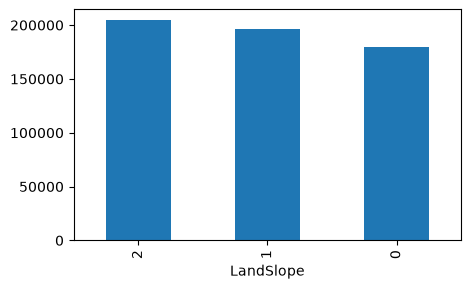

In [1174]:
#LandSlope: Pendiente de la propiedad.
#useTrain.groupby('LandSlope')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))
dsLandSlopeLabels = useTrain['LandSlope'].unique().tolist()
docsLandSlopeLabels = ['Gtl', 'Mod', 'Sev']
misssingLandSlopeLabels = list(set(dsLandSlopeLabels) - set(docsLandSlopeLabels))
display(misssingLandSlopeLabels)
#ordinal encoding/Label encoding para LandSlope.
land_slope_mapping = {'Gtl': 0, 'Mod': 1, 'Sev': 2}
useTrain['LandSlope'] = useTrain['LandSlope'].map(land_slope_mapping)

useTrain.groupby('LandSlope')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

In [1175]:
#Condition2: Proximidad a varias condiciones (si hay más de una presente).
dsCondition2Labels = useTrain['Condition2'].unique().tolist()
docsCondition2Labels = ['Artery', 'Feedr', 'Norm', 'RRNn', 'RRAn', 'PosN', 'PosA', 'RRNe', 'RRAe']
misssingCondition2Labels = list(set(dsCondition2Labels) - set(docsCondition2Labels))
display(misssingCondition2Labels)
#Apliquemos dummy encoding para Condition2.
useTrain = pd.get_dummies(useTrain, columns=['Condition2'], prefix='Condition2', dtype=int, drop_first=True)

[]

In [1176]:
#Condition1: Proximidad a varias condiciones.
dsCondition1Labels = useTrain['Condition1'].unique().tolist()
docsCondition1Labels = ['Artery', 'Feedr', 'Norm', 'RRNn', 'RRAn', 'PosN', 'PosA', 'RRNe', 'RRAe']
misssingCondition1Labels = list(set(dsCondition1Labels) - set(docsCondition1Labels))
display(misssingCondition1Labels)
#Apliquemos dummy encoding para Condition1.
useTrain = pd.get_dummies(useTrain, columns=['Condition1'], prefix='Condition1', dtype=int, drop_first=True)

[]

In [1177]:
#LandContour: Nivel del terreno de la propiedad.
dsLandContourLabels = useTrain['LandContour'].unique().tolist()
docsLandContourLabels = ['Lvl', 'Bnk', 'HLS', 'Low']
misssingLandContourLabels = list(set(dsLandContourLabels) - set(docsLandContourLabels))
display(misssingLandContourLabels)
#Apliquemos dummy encoding para LandContour.
useTrain = pd.get_dummies(useTrain, columns=['LandContour'], prefix='LandContour', dtype=int, drop_first=True)

[]

[]

<Axes: xlabel='LotShape'>

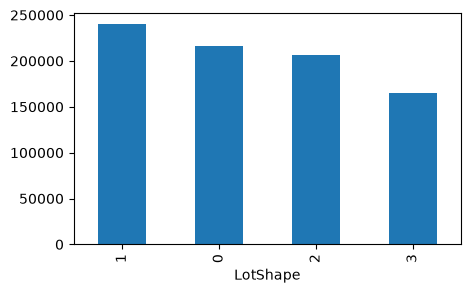

In [1178]:
#LotShape: Forma general de la propiedad.
dsLotShapeLabels = useTrain['LotShape'].unique().tolist()
docsLotShapeLabels = ['Reg', 'IR1', 'IR2', 'IR3']
misssingLotShapeLabels = list(set(dsLotShapeLabels) - set(docsLotShapeLabels))
display(misssingLotShapeLabels)
#Apliquemos ordinal encoding/Label encoding para LotShape.
lotshape_mapping = {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0}
useTrain['LotShape'] = useTrain['LotShape'].map(lotshape_mapping)

useTrain.groupby('LotShape')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))



In [1179]:
#Street: Tipo de acceso por carretera a la propiedad.
dsStreetLabels = useTrain['Street'].unique().tolist()
docsStreetLabels = ['Grvl', 'Pave']
misssingStreetLabels = list(set(dsStreetLabels) - set(docsStreetLabels))
display(misssingStreetLabels)
#Apliquemos dummy encoding para Street.
useTrain = pd.get_dummies(useTrain, columns=['Street'], prefix='Street', dtype=int, drop_first=True)

[]

In [1180]:
#MSZoning: Identifica la clasificación de zonificación general de la venta.
dsMSZoningLabels = useTrain['MSZoning'].unique().tolist()
docsMSZoningLabels = ['A', 'C', 'FV', 'I', 'RH', 'RL', 'RP', 'RM']
misssingMSZoningLabels = list(set(dsMSZoningLabels) - set(docsMSZoningLabels))
display(misssingMSZoningLabels)
useTrain['MSZoning'] = useTrain['MSZoning'].replace('C (all)', 'C')
#Apliquemos dummy encoding para MSZoning.
useTrain = pd.get_dummies(useTrain, columns=['MSZoning'], prefix='MSZoning', dtype=int, drop_first=True)

['C (all)']

[]

<Axes: xlabel='LotConfig'>

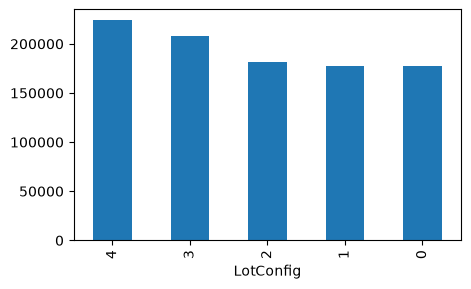

In [1181]:
#LotConfig: Configuración del lote.
dsLotConfigLabels = useTrain['LotConfig'].unique().tolist()
docsLotConfigLabels = ['Inside', 'Corner', 'CulDSac', 'FR2', 'FR3']
misssingLotConfigLabels = list(set(dsLotConfigLabels) - set(docsLotConfigLabels))
display(misssingLotConfigLabels)
useTrain.groupby('LotConfig')['SalePrice'].mean().sort_values(ascending=False).round(2)
#Apliquemos ordinal encoding/Label encoding para LotConfig.
lotconfig_mapping = {'Inside': 0, 'Corner': 2, 'CulDSac': 4, 'FR2': 1, 'FR3': 3}
useTrain['LotConfig'] = useTrain['LotConfig'].map(lotconfig_mapping)

useTrain.groupby('LotConfig')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

[]

<Axes: xlabel='Utilities'>

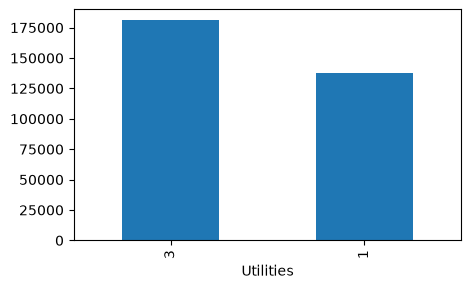

In [1182]:
#Utilities: Tipo de servicios públicos disponibles.
dsUtilitiesLabels = useTrain['Utilities'].unique().tolist()
docsUtilitiesLabels = ['AllPub', 'NoSewr', 'NoSeWa', 'ELO']
misssingUtilitiesLabels = list(set(dsUtilitiesLabels) - set(docsUtilitiesLabels))
display(misssingUtilitiesLabels)
#Apliquemos ordinal encoding/Label encoding para Utilities.
utilities_mapping = {'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0}
useTrain['Utilities'] = useTrain['Utilities'].map(utilities_mapping)

useTrain.groupby('Utilities')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

[]

<Axes: xlabel='HouseStyle'>

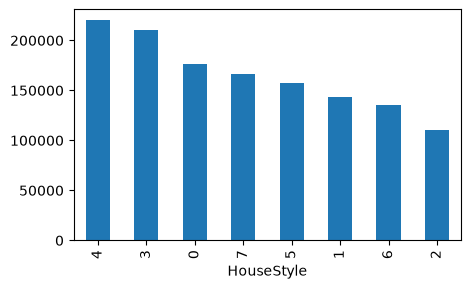

In [1183]:
#HouseStyle: Estilo de vivienda.
dsHouseStyleLabels = useTrain['HouseStyle'].unique().tolist()
docsHouseStyleLabels = ['1Story', '1.5Fin', '1.5Unf', '2Story', '2.5Fin', '2.5Unf', 'SFoyer', 'SLvl']
misssingHouseStyleLabels = list(set(dsHouseStyleLabels) - set(docsHouseStyleLabels))
display(misssingHouseStyleLabels)
#Apliquemos ordinal encoding/Label encoding para HouseStyle.
housestyle_mapping = {'1Story': 0, '1.5Fin': 1, '1.5Unf': 2, '2Story': 3, '2.5Fin': 4, '2.5Unf': 5, 'SFoyer': 6, 'SLvl': 7}
useTrain['HouseStyle'] = useTrain['HouseStyle'].map(housestyle_mapping)
#🎈 Puede ser dummy encoding

useTrain.groupby('HouseStyle')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

[]

<Axes: xlabel='Foundation'>

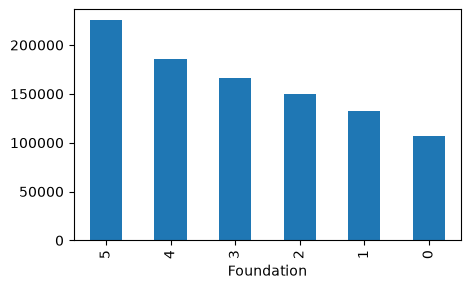

In [1184]:
#Foundation: Tipo de cimientos.
dsFoundationLabels = useTrain['Foundation'].unique().tolist()
docsFoundationLabels = ['BrkTil', 'CBlock', 'PConc', 'Slab', 'Stone', 'Wood']
misssingFoundationLabels = list(set(dsFoundationLabels) - set(docsFoundationLabels))
display(misssingFoundationLabels)
#Apliquemos dummy encoding para Foundation.
#useTrain = pd.get_dummies(useTrain, columns=['Foundation'], prefix='Foundation', dtype=int, drop_first=True)
foundation_mapping = {'Slab': 0, 'BrkTil': 1, 'CBlock': 2, 'Stone': 3, 'Wood': 4, 'PConc': 5}
useTrain['Foundation'] = useTrain['Foundation'].map(foundation_mapping)

useTrain.groupby('Foundation')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

In [1185]:
#ExterQual: Evalúa la calidad del material en el exterior.
dsExterQualLabels = useTrain['ExterQual'].unique().tolist()
docsExterQualLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
misssingExterQualLabels = list(set(dsExterQualLabels) - set(docsExterQualLabels))
display(misssingExterQualLabels)
#Apliquemos ordinal encoding/Label encoding para ExterQual.
exterqual_mapping = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
useTrain['ExterQual'] = useTrain['ExterQual'].map(exterqual_mapping)

[]

In [1186]:
#ExterCond: Evalúa la condición actual del material en el exterior.
dsExterCondLabels = useTrain['ExterCond'].unique().tolist()
docsExterCondLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
misssingExterCondLabels = list(set(dsExterCondLabels) - set(docsExterCondLabels))
display(misssingExterCondLabels)
#Apliquemos ordinal encoding/Label encoding para ExterCond.
extercond_mapping = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
useTrain['ExterCond'] = useTrain['ExterCond'].map(extercond_mapping)

[]

[]

<Axes: xlabel='Heating'>

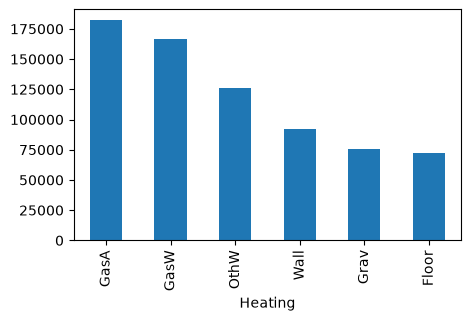

In [1187]:
#Heating: Tipo de calefacción.
dsHeatingLabels = useTrain['Heating'].unique().tolist()
docsHeatingLabels = ['Floor', 'GasA', 'GasW', 'Grav', 'OthW', 'Wall']
misssingHeatingLabels = list(set(dsHeatingLabels) - set(docsHeatingLabels))
display(misssingHeatingLabels)
#Aplicar dummy encoding para Heating.
#useTrain = pd.get_dummies(useTrain, columns=['Heating'], prefix='Heating', dtype=int, drop_first=True)

useTrain.groupby('Heating')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

In [1188]:
#Exterior2nd: Revestimiento exterior de la casa (si hay más de un material).            
dsExterior2ndLabels = useTrain['Exterior2nd'].unique().tolist()
docsExterior2ndLabels = [
  "AsbShng",
  "AsphShn",
  "BrkComm",
  "BrkFace",
  "CBlock",
  "CemntBd",
  "HdBoard",
  "ImStucc",
  "MetalSd",
  "Other",
  "Plywood",
  "PreCast",
  "Stone",
  "Stucco",
  "VinylSd",
  "WdSdng",
  "WdShing"
]
MisssingExterior2ndLabels = list(set(dsExterior2ndLabels) - set(docsExterior2ndLabels))   
display(MisssingExterior2ndLabels)
#Aplicamos dummy encoding para Exterior2nd.
#useTrain = pd.get_dummies(useTrain, columns=['Exterior2nd'], prefix='Exterior2nd', dtype=int, drop_first=True)
useTrain[useTrain['Exterior2nd'] == 'WdSdng']['Exterior2nd']

['Wd Sdng', 'Wd Shng', 'Brk Cmn', 'CmentBd']

Series([], Name: Exterior2nd, dtype: str)

In [1189]:
#Exterior1st: Revestimiento exterior de la casa.
dsExterior1stLabels = useTrain['Exterior1st'].unique().tolist()
docsExterior1stLabels = [
"AsbShng",
"AsphShn",
"BrkComm",
"BrkFace",
"CBlock",
"CemntBd",
"HdBoard",
"ImStucc",
"MetalSd",
"Other",
"Plywood",
"PreCast",
"Stone",
"Stucco",
"VinylSd",
"Wd Sdng",
"WdShing",
]
MisssingExterior1stLabels = list(set(dsExterior1stLabels) - set(docsExterior1stLabels))
display(MisssingExterior1stLabels)
#Aplicamos dummy encoding para Exterior1st.
useTrain = pd.get_dummies(useTrain, columns=['Exterior1st'], prefix='Exterior1st', dtype=int, drop_first=True)

[]

[]

<Axes: xlabel='RoofMatl'>

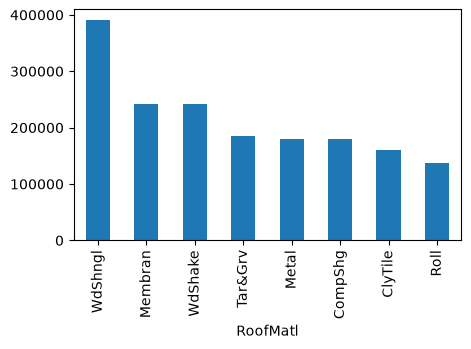

In [1190]:
#RoofMatl: Material del tejado.
dsRoofMatlLabels = useTrain['RoofMatl'].unique().tolist()
docsRoofMatlLabels = [
"ClyTile",
"CompShg",
"Membran",
"Metal",
"Roll",
"Tar&Grv",
"WdShake",
"WdShngl",]
MisssingRoofMatlLabels = list(set(dsRoofMatlLabels) - set(docsRoofMatlLabels))
display(MisssingRoofMatlLabels)
#Apliquemos dummy encoding para RoofMatl.
#useTrain = pd.get_dummies(useTrain, columns=['RoofMatl'], prefix='RoofMatl', dtype=int, drop_first=True)
useTrain.groupby('RoofMatl')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

[]

<Axes: xlabel='RoofStyle'>

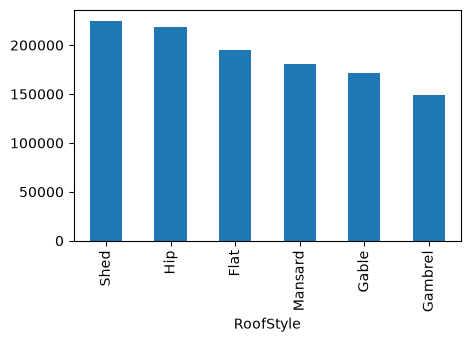

In [1191]:
#RoofStyle: Tipo de tejado.
dsRoofStyleLabels = useTrain['RoofStyle'].unique().tolist()
docsRoofStyleLabels = [
"Flat",
"Gable",
"Gambrel",
"Hip",
"Mansard",
"Shed"]
MisssingRoofStyleLabels = list(set(dsRoofStyleLabels) - set(docsRoofStyleLabels))
display(MisssingRoofStyleLabels)
#Apliquemos dummy encoding para RoofStyle.
#useTrain = pd.get_dummies(useTrain, columns=['RoofStyle'], prefix='RoofStyle', dtype=int, drop_first=True)
useTrain.groupby('RoofStyle')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

[]

<Axes: xlabel='CentralAir'>

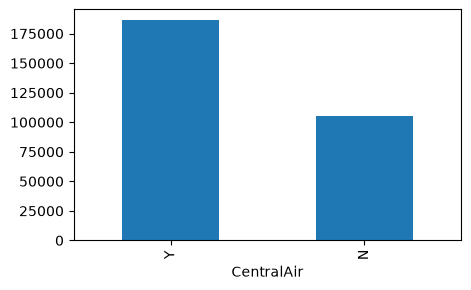

In [1192]:
#CentralAir: Aire acondicionado central.
dsCentralAirLabels = useTrain['CentralAir'].unique().tolist()
docsCentralAirLabels = ['N', 'Y']
MisssingCentralAirLabels = list(set(dsCentralAirLabels) - set(docsCentralAirLabels))
display(MisssingCentralAirLabels)
#Apliquemos dummy encoding para CentralAir.
#useTrain = pd.get_dummies(useTrain, columns=['CentralAir'], prefix='CentralAir', dtype=int, drop_first=True)
useTrain.groupby('CentralAir')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

In [1193]:
#HeatingQC: Calidad y condición de la calefacción.
dsHeatingQCLabels = useTrain['HeatingQC'].unique().tolist()
docsHeatingQCLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
MisssingHeatingQCLabels = list(set(dsHeatingQCLabels) - set(docsHeatingQCLabels))
display(MisssingHeatingQCLabels)
#Apliquemos ordinal encoding/Label encoding para HeatingQC.
heatingqc_mapping = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
useTrain['HeatingQC'] = useTrain['HeatingQC'].map(heatingqc_mapping)

[]

In [1194]:
#KitchenQual: Calidad de la cocina.
dsKitchenQualLabels = useTrain['KitchenQual'].unique().tolist()
docsKitchenQualLabels = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
MisssingKitchenQualLabels = list(set(dsKitchenQualLabels) - set(docsKitchenQualLabels))
display(MisssingKitchenQualLabels)
#Apliquemos ordinal encoding/Label encoding para KitchenQual.
kitchenqual_mapping = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
useTrain['KitchenQual'] = useTrain['KitchenQual'].map(kitchenqual_mapping)

[]

[]

<Axes: xlabel='Functional'>

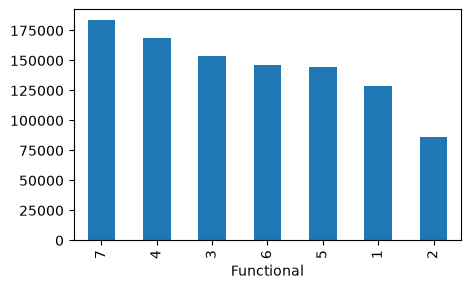

In [1195]:
#Functional: Funcionalidad de la casa (se asume típica a menos que se justifiquen deducciones).
dsFunctionalLabels = useTrain['Functional'].unique().tolist()
docsFunctionalLabels = ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal']
MisssingFunctionalLabels = list(set(dsFunctionalLabels) - set(docsFunctionalLabels))
display(MisssingFunctionalLabels)
#Apliquemos ordinal encoding/Label encoding para Functional.
functional_mapping = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
useTrain['Functional'] = useTrain['Functional'].map(functional_mapping)
useTrain.groupby('Functional')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

[]

<Axes: xlabel='PavedDrive'>

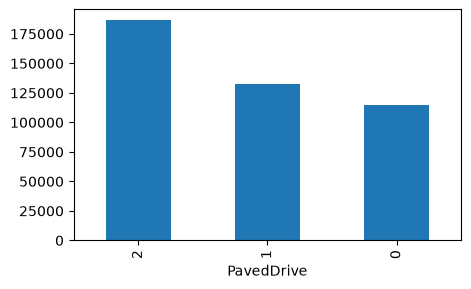

In [1196]:
#PavedDrive: Camino de entrada pavimentado.
dsPavedDriveLabels = useTrain['PavedDrive'].unique().tolist()
docsPavedDriveLabels = ['Y', 'P', 'N']
MisssingPavedDriveLabels = list(set(dsPavedDriveLabels) - set(docsPavedDriveLabels))
display(MisssingPavedDriveLabels)
#Apliquemos ordinal encoding/Label encoding para PavedDrive.
paveddrive_mapping = {'Y': 2, 'P': 1, 'N': 0}
useTrain['PavedDrive'] = useTrain['PavedDrive'].map(paveddrive_mapping)
useTrain.groupby('PavedDrive')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

[]

<Axes: xlabel='SaleType'>

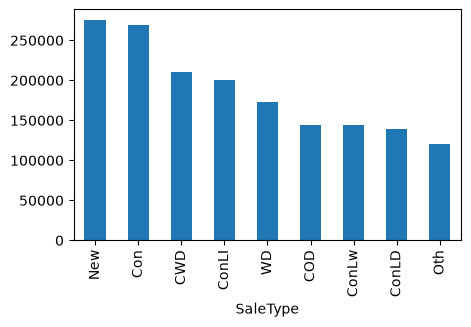

In [1197]:
#SaleType: Tipo de venta.
dsSaleTypeLabels = useTrain['SaleType'].unique().tolist()
docsSaleTypeLabels = ['WD', 'CWD', 'VWD', 'New', 'COD', 'Con', 'ConLw', 'ConLI', 'ConLD', 'Oth']
MisssingSaleTypeLabels = list(set(dsSaleTypeLabels) - set(docsSaleTypeLabels))
display(MisssingSaleTypeLabels)
#Apliquemos dummy encoding para SaleType.
#useTrain = pd.get_dummies(useTrain, columns=['SaleType'], prefix='SaleType', dtype=int, drop_first=True)
useTrain.groupby('SaleType')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

[]

<Axes: xlabel='SaleCondition'>

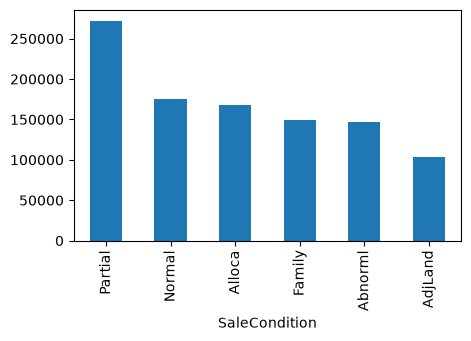

In [1198]:
#SaleCondition: Condición de venta.
dsSaleConditionLabels = useTrain['SaleCondition'].unique().tolist()
docsSaleConditionLabels = ['Normal', 'Abnorml', 'AdjLand', 'Alloca', 'Family', 'Partial']
MisssingSaleConditionLabels = list(set(dsSaleConditionLabels) - set(docsSaleConditionLabels))
display(MisssingSaleConditionLabels)
#Apliquemos dummy encoding para SaleCondition.
#useTrain = pd.get_dummies(useTrain, columns=['SaleCondition'], prefix='SaleCondition', dtype=int, drop_first=True)
useTrain.groupby('SaleCondition')['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5, 3))

In [1199]:
#useTrain.to_csv("../data/processed/train_encoded.csv", index=False)